20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step


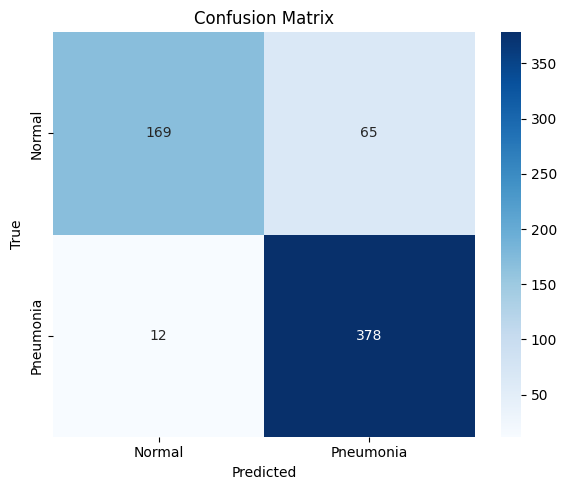

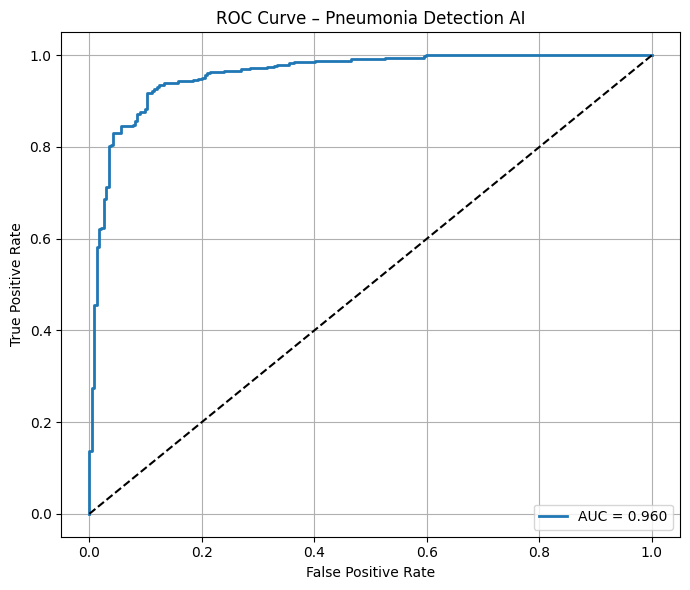


✅ Confusion Matrix & ROC Curve generated successfully!
📁 Saved at: C:\Pneumonia_Project\results


In [15]:
# ==============================================
# 📊 Confusion Matrix + ROC Curve (No History Needed)
# ==============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Folder to save images
out_dir = r"C:\Pneumonia_Project\results"
os.makedirs(out_dir, exist_ok=True)

# ------------------------------
# TRUE LABELS
# ------------------------------
true_labels = test_data.classes  # Already built-in, no loops

# ------------------------------
# PREDICT PROBABILITIES
# ------------------------------
pred_probs = model.predict(test_data, verbose=1)

# If model output shape is (N,1)
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()

# Convert probability → predicted class
pred_classes = (pred_probs > 0.5).astype(int)

# ==========================================================
# 1️⃣ CONFUSION MATRIX
# ==========================================================
cm = confusion_matrix(true_labels, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix.png"))
plt.show()

# ==========================================================
# 2️⃣ ROC CURVE
# ==========================================================
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection AI")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "roc_curve.png"))
plt.show()

print("\n✅ Confusion Matrix & ROC Curve generated successfully!")
print(f"📁 Saved at: {out_dir}")


In [14]:
import numpy as np

# Load saved history
history_dict = np.load(r"C:\Pneumonia_Project\history.npy", allow_pickle=True).item()

# Convert the dictionary back into a history-like object
history = type('History', (object,), {'history': history_dict})

print("History loaded successfully!")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Pneumonia_Project\\history.npy'

In [13]:
import numpy as np

history_dict = np.load("history.npy", allow_pickle=True).item()

history = type('obj', (object,), {'history': history_dict})
print("History loaded!")


FileNotFoundError: [Errno 2] No such file or directory: 'history.npy'

In [12]:
# ======================================================
# 📊 Generate ALL graphs for IEEE paper/PPT 
# (Accuracy, Loss, Confusion Matrix, ROC Curve)
# Saves output images in: C:\Pneumonia_Project\results\
# ======================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# --------- Create output folder ----------
out_dir = r"C:\Pneumonia_Project\results"
os.makedirs(out_dir, exist_ok=True)

# --------- 1. Accuracy Graph ----------
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "accuracy.png"))
plt.show()

# --------- 2. Loss Graph ----------
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "loss.png"))
plt.show()

# --------- Get true labels & predictions ----------
true_labels = test_data.classes

pred_probs = model.predict(test_data, verbose=1)

# Convert to 1D
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()

pred_classes = (pred_probs > 0.5).astype(int)

# --------- 3. Confusion Matrix ----------
cm = confusion_matrix(true_labels, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix.png"))
plt.show()

# --------- 4. ROC Curve ----------
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", lw=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "roc_curve.png"))
plt.show()

print("\n✅ All graphs generated & saved successfully!")
print(f"📁 Saved in: {out_dir}")


NameError: name 'history' is not defined

<Figure size 700x500 with 0 Axes>

In [11]:
!pip install seaborn


   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 1.3 MB/s eta 0:00:09
   - -------------------------------------- 0.5/11.0 MB 1.3 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.0 MB 1.1 MB/s eta 0:00:10
   --- ------------------------------------ 1.0/11.0 MB 915.5 kB/s eta 0:00:11
   ---- ----------------------------------- 1.3/11.0 MB 1.0 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/11.0 MB 1.2 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.0 MB 1.3 MB/s eta 0:00:08
   --------- ------------------------------ 2.6/11.0 MB 1.4 MB/s eta 0:00:06
   ------------ --------------------------- 3.4/11.0 MB 1.6 MB/s eta 0:00:05
   -------------- ------------------------- 3.9/11.0 MB 1.8 MB/s eta 0:00:04
   ------------------ --------------------- 5.0/11.0 MB 2.0 MB/s eta 0:00:03
   --------

In [10]:
# ======================================================
# 📊 Generate ALL graphs for IEEE paper/PPT 
# (Accuracy, Loss, Confusion Matrix, ROC Curve)
# Saves output images in: C:\Pneumonia_Project\results\
# ======================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# --------- Create output folder ----------
out_dir = r"C:\Pneumonia_Project\results"
os.makedirs(out_dir, exist_ok=True)

# --------- 1. Accuracy Graph ----------
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "accuracy.png"))
plt.show()

# --------- 2. Loss Graph ----------
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "loss.png"))
plt.show()

# --------- Get true labels & predictions ----------
true_labels = test_data.classes
pred_probs = model.predict(test_data, verbose=1)

# Convert to 1D
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()
pred_classes = (pred_probs > 0.5).astype(int)

# --------- 3. Confusion Matrix ----------
cm = confusion_matrix(true_labels, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix.png"))
plt.show()

# --------- 4. ROC Curve ----------
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", lw=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "roc_curve.png"))
plt.show()

print("\n✅ All graphs generated & saved successfully!")
print(f"📁 Saved in: {out_dir}")


ModuleNotFoundError: No module named 'seaborn'

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step


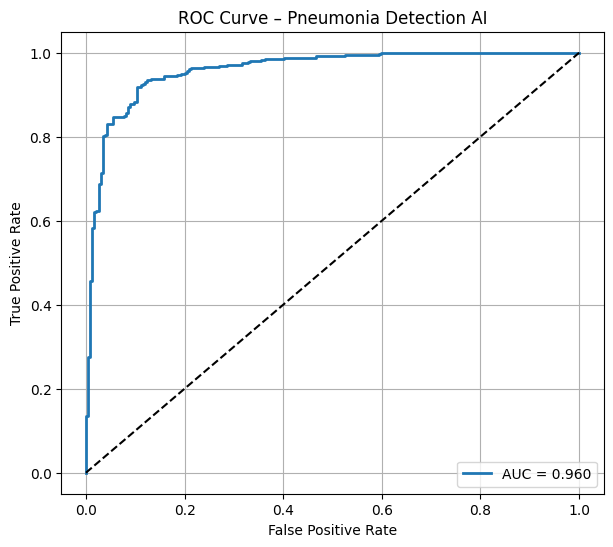

In [9]:
# ============================
# FAST & SAFE ROC CURVE
# ============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# true labels
true_labels = test_data.classes

# predictions
pred_probs = model.predict(test_data, verbose=1)

# flatten predictions
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()
else:
    pred_probs = pred_probs[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", lw=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection AI")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = r"C:\Pneumonia_Project\chest_xray"

test_datagen = ImageDataGenerator(rescale=1.0/255)

test_data = test_datagen.flow_from_directory(
    base_dir + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


In [7]:
import tensorflow as tf

MODEL_PATH = r"C:\Pneumonia_Project\pneumonia_mobilenetv2_final.h5"
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")


Model loaded successfully!


In [6]:
# ============================
# FAST & SAFE ROC CURVE
# ============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# true labels (NO LOOP — FAST)
true_labels = test_data.classes

# predictions
pred_probs = model.predict(test_data, verbose=1)

# flatten predictions
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()
else:
    pred_probs = pred_probs[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", lw=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection AI")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


NameError: name 'model' is not defined

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = r"C:\Pneumonia_Project\chest_xray"

test_datagen = ImageDataGenerator(rescale=1.0/255)

test_data = test_datagen.flow_from_directory(
    base_dir + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


In [3]:
# ============================================
# 🟦 ROC Curve for Pneumonia Detection Model
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Get true labels ---
true_labels = []
for _, y in test_data:   # test_data = ImageDataGenerator.flow_from_directory()
    true_labels.extend(y)
true_labels = np.array(true_labels)

# --- Get predicted probabilities (model output) ---
pred_probs = model.predict(test_data, verbose=1)

# If model output is shape (N,1)
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()
else:
    pred_probs = pred_probs[:, 1]  # probability of pneumonia class

# --- Calculate ROC Curve ---
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# --- Plot ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


NameError: name 'test_data' is not defined

In [2]:
# ============================================
# 🟦 ROC Curve for Pneumonia Detection Model
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Get true labels ---
true_labels = []
for _, y in test_data:   # test_data = ImageDataGenerator.flow_from_directory()
    true_labels.extend(y)
true_labels = np.array(true_labels)

# --- Get predicted probabilities (model output) ---
pred_probs = model.predict(test_data, verbose=1)

# If model output is shape (N,1)
if pred_probs.shape[1] == 1:
    pred_probs = pred_probs.ravel()
else:
    pred_probs = pred_probs[:, 1]  # probability of pneumonia class

# --- Calculate ROC Curve ---
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# --- Plot ROC Curve ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Pneumonia Detection Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


NameError: name 'test_data' is not defined

In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions (probabilities)
y_pred_prob = model.predict(test_generator)

# True labels
y_true = test_generator.classes

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.savefig("roc_curve.png")  # Save image
plt.show()


NameError: name 'model' is not defined

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r"C:\Pneumonia_Project\chest_xray\test"
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")


Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8153 - loss: 0.4538

✅ Final Test Accuracy: 87.66%


In [32]:
model.save(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_final.h5")
print("✅ Final model saved successfully!")


✅ Final model saved successfully!


In [31]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    verbose=1
)


Epoch 1/3


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.7103 - loss: 1.1514 - val_accuracy: 0.8125 - val_loss: 0.3391
Epoch 2/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.9594 - loss: 0.1150 - val_accuracy: 0.9375 - val_loss: 0.3001
Epoch 3/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.9725 - loss: 0.0791 - val_accuracy: 0.9375 - val_loss: 0.2633


In [30]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# --- Reload your latest balanced model (or your base model) ---
model = load_model(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_balanced.h5")

# --- (Optional) Unfreeze top layers if you want to fine-tune ---
for layer in model.layers[-30:]:
    layer.trainable = True

# --- ✅ Recreate a fresh optimizer instance ---
optimizer = Adam(learning_rate=1e-5)

# --- ✅ Recompile the model to register new trainable vars ---
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model recompiled successfully with a new optimizer.")


✅ Model recompiled successfully with a new optimizer.


In [29]:
train_dir = r"C:\Pneumonia_Project\chest_xray_balanced\train"
val_dir   = r"C:\Pneumonia_Project\chest_xray\val"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=True
)
val_data = val_gen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False
)

model.fit(train_data, validation_data=val_data, epochs=3)


Found 7750 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/3


ValueError: Unknown variable: <KerasVariable shape=(3, 3, 960, 1), dtype=float32, path=block_14_depthwise/kernel>. This optimizer can only be called for the variables it was originally built with. When working with a new set of variables, you should recreate a new optimizer instance.

In [28]:
import os, shutil, random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

src_dir = r"C:\Pneumonia_Project\chest_xray\train"
dst_dir = r"C:\Pneumonia_Project\chest_xray_balanced\train"
os.makedirs(os.path.join(dst_dir, "NORMAL"), exist_ok=True)
os.makedirs(os.path.join(dst_dir, "PNEUMONIA"), exist_ok=True)

normal_dir = os.path.join(src_dir, "NORMAL")
pneu_dir   = os.path.join(src_dir, "PNEUMONIA")

normal_files = os.listdir(normal_dir)
pneu_files   = os.listdir(pneu_dir)
print(f"NORMAL={len(normal_files)}, PNEUMONIA={len(pneu_files)}")

# Copy all pneumonia files
for f in pneu_files:
    shutil.copy(os.path.join(pneu_dir, f), os.path.join(dst_dir, "PNEUMONIA"))

# Copy all normal files, then augment until counts match
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = len(pneu_files)
print("Target per class:", target_count)

# save originals
for f in normal_files:
    shutil.copy(os.path.join(normal_dir, f), os.path.join(dst_dir, "NORMAL"))

# generate augmented images
gen = datagen.flow_from_directory(
    src_dir,
    classes=['NORMAL'],
    target_size=(224,224),
    batch_size=1,
    class_mode=None,
    save_to_dir=os.path.join(dst_dir, "NORMAL"),
    save_prefix='aug',
    save_format='jpeg'
)

needed = target_count - len(normal_files)
print(f"Generating {needed} augmented NORMAL images...")
for i in range(needed):
    next(gen)
print("✅ Balanced dataset created at:", dst_dir)


NORMAL=1341, PNEUMONIA=3875
Target per class: 3875
Found 1341 images belonging to 1 classes.
Generating 2534 augmented NORMAL images...
✅ Balanced dataset created at: C:\Pneumonia_Project\chest_xray_balanced\train


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# --- Load the new model ---
model = load_model(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_balanced.h5")
print("✅ Balanced model loaded.")

# --- Prepare test generator ---
test_dir = r"C:\Pneumonia_Project\chest_xray\test"
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# --- Evaluate ---
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

# --- Detailed metrics ---
y_probs = model.predict(test_data)
y_pred = (y_probs > 0.5).astype(int).reshape(-1)
y_true = test_data.classes

print("\n✅ Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\n✅ Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))


✅ Balanced model loaded.
Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6218 - loss: 0.6469

✅ Test Loss: 0.4971
✅ Test Accuracy: 0.7500
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step

✅ Confusion Matrix:
[[105 129]
 [ 27 363]]

✅ Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.80      0.45      0.57       234
   PNEUMONIA       0.74      0.93      0.82       390

    accuracy                           0.75       624
   macro avg       0.77      0.69      0.70       624
weighted avg       0.76      0.75      0.73       624



In [26]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# --- Load your previously trained model ---
model = load_model(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5")
print("✅ Model loaded.")

# --- Unfreeze top layers for fine-tuning ---
for layer in model.layers[-30:]:
    layer.trainable = True

# --- Compile again with smaller learning rate ---
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- Callbacks to prevent overfitting ---
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=1, verbose=1
)

# --- Train with balanced generator ---
history = model.fit(
    balanced_train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_data,
    epochs=3,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Save the newly balanced model ---
model.save(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_balanced.h5")
print("✅ Training completed and model saved successfully as 'pneumonia_mobilenetv2_balanced.h5'")


✅ Model loaded.
Epoch 1/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4082 - loss: 2.3427

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 904s 4s/step - accuracy: 0.4096 - loss: 2.3368 - val_accuracy: 0.5000 - val_loss: 5.3276 - learning_rate: 1.0000e-05
Epoch 2/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 707s 3s/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 0.5000 - val_loss: 2.4681 - learning_rate: 1.0000e-05
Epoch 3/3
243/243 ━━━━━━━━━━━━━━━━━━━━ 625s 3s/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.5625 - val_loss: 0.8203 - learning_rate: 1.0000e-05


✅ Training completed and model saved successfully as 'pneumonia_mobilenetv2_balanced.h5'


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import math

train_dir = r"C:\Pneumonia_Project\chest_xray\train"
val_dir   = r"C:\Pneumonia_Project\chest_xray\val"

# Create two separate generators: one for each class
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

# Load separately
normal_gen = datagen.flow_from_directory(
    train_dir,
    classes=['NORMAL'],
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)
pneu_gen = datagen.flow_from_directory(
    train_dir,
    classes=['PNEUMONIA'],
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

# Oversample NORMAL to match PNEUMONIA
steps_per_epoch = math.ceil(max(normal_gen.samples, pneu_gen.samples) / 16)

# Combine the two generators into one balanced generator
def balanced_generator():
    while True:
        x_n, y_n = next(normal_gen)
        x_p, y_p = next(pneu_gen)
        x = np.concatenate([x_n, x_p])
        y = np.concatenate([y_n, y_p])
        idx = np.random.permutation(len(x))
        yield x[idx], y[idx]

balanced_train_gen = balanced_generator()

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

print("✅ Balanced generator created successfully.")


Found 1341 images belonging to 1 classes.
Found 3875 images belonging to 1 classes.
Found 16 images belonging to 2 classes.
✅ Balanced generator created successfully.


In [24]:
import os

train_dir = r"C:\Pneumonia_Project\chest_xray\train"

normal_path = os.path.join(train_dir, "NORMAL")
pneu_path   = os.path.join(train_dir, "PNEUMONIA")

normal_count = len(os.listdir(normal_path))
pneu_count   = len(os.listdir(pneu_path))

print(f"NORMAL images   = {normal_count}")
print(f"PNEUMONIA images = {pneu_count}")


NORMAL images   = 1341
PNEUMONIA images = 3875


In [23]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

train_dir = r"C:\Pneumonia_Project\chest_xray\train"
val_dir   = r"C:\Pneumonia_Project\chest_xray\val"

# Slight augmentation to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("✅ Data generators ready.")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
✅ Data generators ready.


In [22]:
import json, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing import image

# --- paths (change only if these files don't exist) ---
MODEL_PATH = r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5"
CLASS_PATH = r"C:\Pneumonia_Project\class_indices.json"
NORMAL_SAMPLE = r"C:\Pneumonia_Project\chest_xray\test\NORMAL\IM-0001-0001.jpeg"
PNEU_SAMPLE   = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person1_virus_11.jpeg"

# --- load model & class indices ---
model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASS_PATH, 'r') as f:
    class_indices = json.load(f)
idx2class = {v:k for k,v in class_indices.items()}

print("CLASS INDICES:", class_indices)
print("IDX2CLASS:", idx2class)
print("MODEL OUTPUT SHAPE:", model.output_shape)   # shows (None,1) or (None,2)

def raw_predict(path):
    img = image.load_img(path, target_size=(224,224))
    x = image.img_to_array(img)/255.0
    x = np.expand_dims(x,0)
    probs = model.predict(x)
    print(f"\nFILE: {path}")
    print("raw probs:", probs)
    if probs.shape[1] == 1:
        p = float(probs[0][0])
        print("interpreted (sigmoid): p=", p)
    else:
        print("interpreted (softmax): argmax=", int(np.argmax(probs,axis=1)[0]))

# Run predictions for both samples
raw_predict(NORMAL_SAMPLE)
raw_predict(PNEU_SAMPLE)


CLASS INDICES: {'NORMAL': 0, 'PNEUMONIA': 1}
IDX2CLASS: {0: 'NORMAL', 1: 'PNEUMONIA'}
MODEL OUTPUT SHAPE: (None, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

FILE: C:\Pneumonia_Project\chest_xray\test\NORMAL\IM-0001-0001.jpeg
raw probs: [[0.9642706]]
interpreted (sigmoid): p= 0.9642705917358398
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

FILE: C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person1_virus_11.jpeg
raw probs: [[0.99783087]]
interpreted (sigmoid): p= 0.997830867767334


In [21]:
class_mode='binary'


In [20]:
probs = model.predict(x)
print("Raw output:", probs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Raw output: [[0.99783087]]


In [17]:
import json
with open(r"C:\Pneumonia_Project\class_indices.json", 'r') as f:
    class_indices = json.load(f)
print("Class Indices:", class_indices)


Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
import json, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing import image

MODEL_PATH  = r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5"
CLASS_PATH  = r"C:\Pneumonia_Project\class_indices.json"
SAMPLE_IMG  = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person1_virus_11.jpeg"

model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASS_PATH, 'r') as f:
    class_indices = json.load(f)
idx2class = {v:k for k,v in class_indices.items()}

img = image.load_img(SAMPLE_IMG, target_size=(224,224))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0)

probs = model.predict(x)
if probs.shape[1] == 1:
    p = float(probs[0][0])
    label = 'PNEUMONIA' if p > 0.5 else 'NORMAL'
    conf = p if label == 'PNEUMONIA' else 1 - p
else:
    idx = int(np.argmax(probs, axis=1)[0])
    label = idx2class[idx]
    conf = float(np.max(probs))

print(f"✅ Prediction: {label} | Confidence: {conf*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ Prediction: PNEUMONIA | Confidence: 99.78%


In [15]:
import json, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing import image

# === Paths ===
MODEL_PATH  = r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5"
CLASS_PATH  = r"C:\Pneumonia_Project\class_indices.json"
SAMPLE_IMG  = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person1_virus_11.jpeg"

# === Load model and class indices ===
model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASS_PATH, 'r') as f:
    class_indices = json.load(f)
idx2class = {v: k for k, v in class_indices.items()}

# === Prepare image ===
img = image.load_img(SAMPLE_IMG, target_size=(224, 224))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, 0)

# === Predict ===
probs = model.predict(x)

# handle both binary and 2-class outputs
if probs.shape[1] == 1:                 # binary sigmoid output
    p = float(probs[0][0])
    label = "PNEUMONIA" if p > 0.5 else "NORMAL"
    conf  = p if label == "PNEUMONIA" else 1 - p
else:                                   # softmax 2-class output
    idx   = int(np.argmax(probs, axis=1)[0])
    label = idx2class[idx]
    conf  = float(np.max(probs))

print(f"✅ Prediction: {label}  |  Confidence: {conf*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ Prediction: PNEUMONIA  |  Confidence: 99.78%


In [14]:
import json, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing import image

MODEL_PATH = r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5"
CLASS_PATH = r"C:\Pneumonia_Project\class_indices.json"
SAMPLE_IMG = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person1_bacteria_1.jpeg"  # change if needed

model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASS_PATH,'r') as f:
    class_indices = json.load(f)
idx2class = {v:k for k,v in class_indices.items()}

img = image.load_img(SAMPLE_IMG, target_size=(224,224))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x,0)
probs = model.predict(x)
# If model outputs single probability (sigmoid)
if probs.shape[1] == 1:
    p = float(probs[0][0])
    label = 'PNEUMONIA' if p > 0.5 else 'NORMAL'
    conf = p if label=='PNEUMONIA' else 1-p
else:
    idx = int(np.argmax(probs, axis=1)[0])
    label = idx2class[idx]
    conf = float(np.max(probs))
print("Prediction:", label, "Confidence:", f"{conf:.3f}")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Pneumonia_Project\\chest_xray\\test\\PNEUMONIA\\person1_bacteria_1.jpeg'

In [13]:
import json
# if your test_data generator exists use that mapping, otherwise replace with your mapping
# example: {'NORMAL': 0, 'PNEUMONIA': 1}
class_indices = test_data.class_indices  # or set manually if test_data not in memory
with open(r"C:\Pneumonia_Project\class_indices.json", 'w') as f:
    json.dump(class_indices, f)
print("Saved:", r"C:\Pneumonia_Project\class_indices.json")
print("Mapping:", class_indices)


Saved: C:\Pneumonia_Project\class_indices.json
Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [12]:
import os
print(os.path.exists(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5"))


True


In [11]:
model.save(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5")


In [10]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2984 - loss: 3.1932
✅ Test Loss: 1.7657
✅ Test Accuracy: 0.6250


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r"C:\Pneumonia_Project\chest_xray\test"
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


In [8]:
from tensorflow import keras
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("✅ Model recompiled successfully!")


✅ Model recompiled successfully!


In [7]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r"C:\Pneumonia_Project\chest_xray\test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',   # ✅ FIXED: use 'binary' instead of 'categorical'
    shuffle=False
)


Found 624 images belonging to 2 classes.


In [5]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 2), output.shape=(None, 1)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = r"C:\Pneumonia_Project\chest_xray\test"

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 624 images belonging to 2 classes.


In [3]:
from tensorflow import keras

# Load the correct file that was saved during training
model = keras.models.load_model(r"C:\Pneumonia_Project\pneumonia_mobilenet_model.keras")
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [2]:
from tensorflow import keras

model = keras.models.load_model(r"C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5")
print("✅ Model loaded successfully!")



FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'C:\Pneumonia_Project\pneumonia_mobilenetv2_weighted.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [1]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")



NameError: name 'model' is not defined

In [1]:
print("STEP 2 — notebook output OK")


STEP 2 — notebook output OK


In [7]:
# 2. Evaluate on test set
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

# Predictions -> class indices depend on your generator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# If test_data is a generator:
steps = int(np.ceil(test_data.samples / test_data.batch_size))
y_probs = model.predict(test_data, steps=steps, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_data.classes  # generator attribute

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("Classification Report:")
target_names = list(test_data.class_indices.keys())  # e.g. ['NORMAL','PNEUMONIA']
print(target_names)
print(classification_report(y_true, y_pred, target_names=target_names))


20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8544 - loss: 0.3751
Test loss: 0.3610  Test accuracy: 0.8574


AttributeError: '_PrefetchDataset' object has no attribute 'samples'

In [6]:
# 1. Check history keys and final metrics
print("History keys:", history.history.keys())

acc = history.history.get('accuracy') or history.history.get('acc')
val_acc = history.history.get('val_accuracy') or history.history.get('val_acc')
loss = history.history.get('loss')
val_loss = history.history.get('val_loss')

print("Final training accuracy:", acc[-1])
print("Final validation accuracy:", val_acc[-1])
print("Final training loss:", loss[-1])
print("Final validation loss:", val_loss[-1])


History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Final training accuracy: 0.935774564743042
Final validation accuracy: 0.75
Final training loss: 0.23204244673252106
Final validation loss: 0.5523167848587036


In [5]:
epochs = 5  
class_weights = {0: 3.0, 1: 1.0}

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("✅ Training completed successfully with class weights!")


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8521 - loss: 0.4827
Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to pneumonia_mobilenet_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.8523 - loss: 0.4822 - val_accuracy: 0.7500 - val_loss: 1.0593
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9123 - loss: 0.2935
Epoch 2: val_accuracy did not improve from 0.75000
163/163 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.9123 - loss: 0.2934 - val_accuracy: 0.7500 - val_loss: 0.6563
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9271 - loss: 0.2649
Epoch 3: val_accuracy did not improve from 0.75000
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9272 - loss: 0.2648 - val_accuracy: 0.6875 - val_loss: 0.9989
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9408 - loss: 0.2122
Epoch 4: val_accuracy did not improve from 0.75000
163/163 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.

In [4]:
checkpoint = ModelCheckpoint(
    "pneumonia_mobilenet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, earlystop]
print("✅ Callbacks ready!")


✅ Callbacks ready!


In [3]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [2]:
train_dir = r"C:\Pneumonia_Project\chest_xray\train"
val_dir = r"C:\Pneumonia_Project\chest_xray\val"
test_dir = r"C:\Pneumonia_Project\chest_xray\test"

train_data = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)
val_data = image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)
test_data = image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32
)

print("✅ Dataset loaded successfully!")


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
✅ Dataset loaded successfully!


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [10]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the trained model
model = load_model("pneumonia_mobilenet_model.keras")
print("✅ Model reloaded successfully!")

# Automatically pick one image from your test set (PNEUMONIA folder)
test_folder = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA"
test_images = os.listdir(test_folder)

# Pick the first image in the list
img_path = os.path.join(test_folder, test_images[0])
print(f"\n🩻 Using sample image: {img_path}")

# Load and predict
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0][0]
label = "PNEUMONIA" if pred > 0.5 else "NORMAL"
confidence = pred if pred > 0.5 else 1 - pred

print(f"\nPrediction: {label} ({confidence*100:.2f}% confidence)")


✅ Model reloaded successfully!

🩻 Using sample image: C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Prediction: PNEUMONIA (74.56% confidence)


In [9]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model
model = load_model("pneumonia_mobilenet_model.keras")
print("✅ Model reloaded successfully!")

# Test it on one image from your dataset (or your own image)
img_path = r"C:\Pneumonia_Project\chest_xray\test\PNEUMONIA\person100_bacteria_470.jpeg"  # example file
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0][0]
label = "PNEUMONIA" if pred > 0.5 else "NORMAL"
confidence = pred if pred > 0.5 else 1 - pred

print(f"\n🩻 Prediction: {label} ({confidence*100:.2f}% confidence)")


✅ Model reloaded successfully!


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Pneumonia_Project\\chest_xray\\test\\PNEUMONIA\\person100_bacteria_470.jpeg'

In [8]:
!pip freeze > requirements.txt
print("✅ requirements.txt created in your project folder")


✅ requirements.txt created in your project folder


In [7]:
# Check true labels for the selected samples
for idx in [0, 10, 50, 100, 200]:
    true_label = "PNEUMONIA" if test_data.classes[idx] == 1 else "NORMAL"
    print(f"Image index {idx}: True label = {true_label}")


Image index 0: True label = NORMAL
Image index 10: True label = NORMAL
Image index 50: True label = NORMAL
Image index 100: True label = NORMAL
Image index 200: True label = NORMAL


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


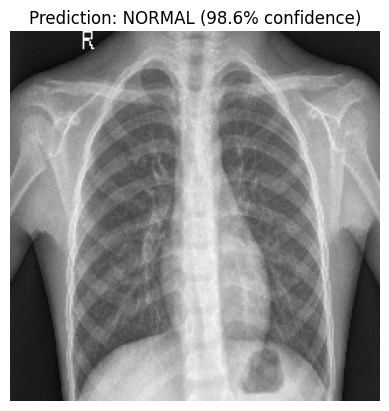

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


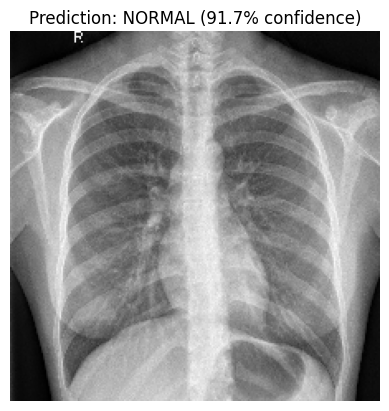

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


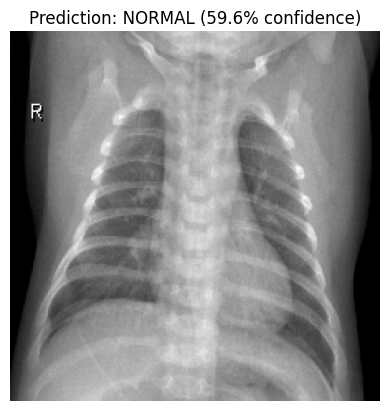

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


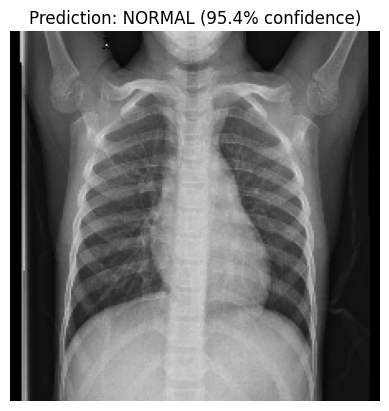

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


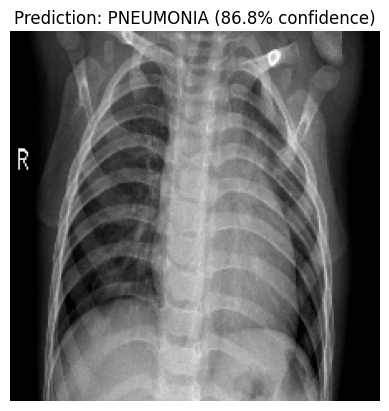

In [6]:
# Step 9: Visualize sample predictions
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Pick a few random test images
sample_idxs = [0, 10, 50, 100, 200]  # you can change these
filenames = np.array(test_data.filepaths)

for idx in sample_idxs:
    img_path = filenames[idx]
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    
    pred = model.predict(x)[0][0]
    label = "PNEUMONIA" if pred > 0.5 else "NORMAL"
    confidence = pred if pred > 0.5 else 1 - pred

    plt.imshow(img)
    plt.title(f"Prediction: {label} ({confidence*100:.1f}% confidence)")
    plt.axis("off")
    plt.show()


In [5]:
# Evaluate on test dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_data.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7897 - loss: 0.4805

🧪 Test Accuracy: 0.8670
📉 Test Loss: 0.3091
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.68      0.79       234
   PNEUMONIA       0.84      0.98      0.90       390

    accuracy                           0.87       624
   macro avg       0.89      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624


Confusion Matrix:
[[159  75]
 [  8 382]]


In [4]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define base directory
base_dir = r"C:\Pneumonia_Project\chest_xray"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Create data generators
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Only recreate the test data (we don’t need to train again)
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("✅ Test dataset reloaded successfully!")


Found 624 images belonging to 2 classes.
✅ Test dataset reloaded successfully!


In [3]:
# Evaluate on test dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_data.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


NameError: name 'test_data' is not defined

In [2]:
from tensorflow.keras.models import load_model

# Load the best saved model
model = load_model("pneumonia_mobilenet_model.keras")

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [1]:
# Cell 8: Evaluate on test dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

# Get model predictions
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_data.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


NameError: name 'model' is not defined

In [10]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.7 MB 1.7 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.7 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.7 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.7 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.7 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.7 MB 2.0 MB/s eta 0:00:04
   --------------- ------------------------ 3.4/8.7 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 4.2/8.7 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.7 MB 2.6 MB/s eta 0:00:02
   -------------------------- ------------- 5.8/8.7 MB 2.7 MB/s eta 0:00:02
   ------------------------------- -------- 6.8/8.7 MB 2.9 MB/s eta 0:00:01
   -----------------------

In [9]:
# Cell 8: Evaluate on test dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

# Get model predictions
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_data.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


ModuleNotFoundError: No module named 'sklearn'

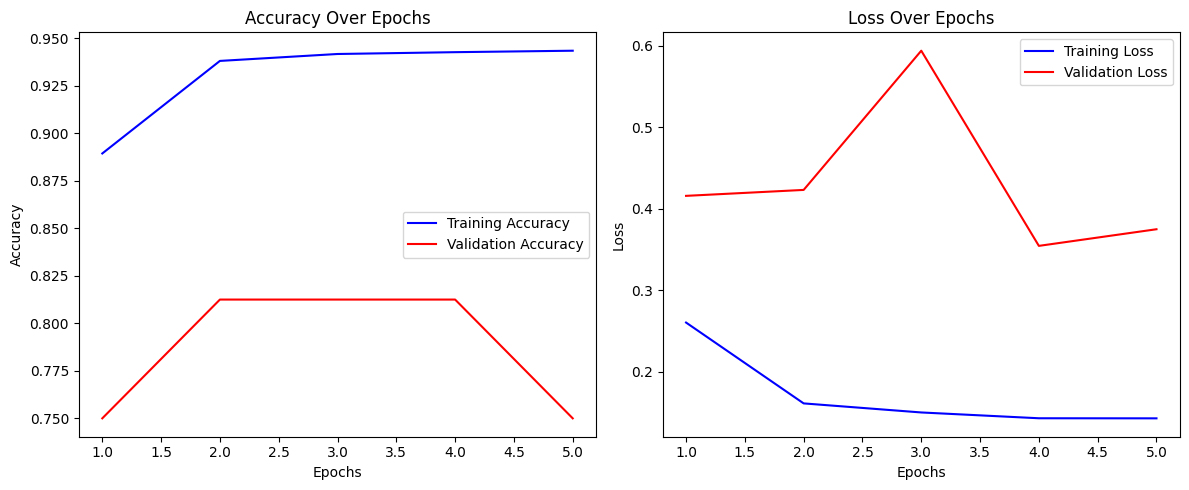

In [8]:
# Cell 7: Plot accuracy and loss curves
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [1]:
# Number of epochs — you can increase later if needed (e.g., 10 or 15)
epochs = 5  

# Define class weights to balance NORMAL (0) and PNEUMONIA (1)
# NORMAL: fewer images → higher weight (e.g., 3.0)
# PNEUMONIA: more images → lower weight (1.0)
class_weights = {0: 3.0, 1: 1.0}

# Start training with class weighting
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("✅ Training completed successfully with class weights!")


NameError: name 'model' is not defined

In [6]:
# Cell 5 (fixed): callbacks (recommended)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (new Keras format)
checkpoint = ModelCheckpoint(
    "pneumonia_mobilenet_model.keras",  # 👈 changed .h5 → .keras
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop early if val_loss stops improving
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, earlystop]

print("✅ Callbacks are set up successfully (using .keras format)!")


✅ Callbacks are set up successfully (using .keras format)!


In [5]:
# Cell 5: callbacks (recommended)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model (highest val_accuracy)
checkpoint = ModelCheckpoint(
    "pneumonia_mobilenet_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop early if val_loss stops improving
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, earlystop]

print("✅ Callbacks are set up successfully!")


ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=pneumonia_mobilenet_model.h5

In [4]:
# Cell 4: build the MobileNetV2 based model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load base MobileNetV2 (pretrained on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers to retain pretrained features
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
# Cell 3: create ImageDataGenerators and flow_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='binary'
)
val_data = val_test_datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='binary'
)
test_data = val_test_datagen.flow_from_directory(
    test_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [2]:
# Cell 2: paths and quick file check
base_dir = r"C:\Pneumonia_Project\chest_xray"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

print("Base dir exists:", os.path.exists(base_dir))
print("Train dir exists:", os.path.exists(train_dir))
print("Val dir exists:", os.path.exists(val_dir))
print("Test dir exists:", os.path.exists(test_dir))

# List counts
for folder in ["train","val","test"]:
    n_normal = len(os.listdir(os.path.join(base_dir,folder,"NORMAL")))
    n_pneu   = len(os.listdir(os.path.join(base_dir,folder,"PNEUMONIA")))
    print(f"{folder.upper():5} → NORMAL: {n_normal}, PNEUMONIA: {n_pneu}")


Base dir exists: True
Train dir exists: True
Val dir exists: True
Test dir exists: True
TRAIN → NORMAL: 1341, PNEUMONIA: 3875
VAL   → NORMAL: 8, PNEUMONIA: 8
TEST  → NORMAL: 234, PNEUMONIA: 390


In [1]:
# Cell 1: imports and quick checks
import os
import sys
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version.splitlines()[0])
print("TensorFlow:", tf.__version__)

# Confirm scipy is available
import scipy
print("scipy:", scipy.__version__)


Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
TensorFlow: 2.17.0
scipy: 1.16.3


In [5]:
!pip install scipy


In [4]:
# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,   # you can increase to 10 or 15 later
    verbose=1
)

# Save the trained model
model.save("pneumonia_mobilenet_model.h5")

print("✅ Model training complete and saved as pneumonia_mobilenet_model.h5")


ImportError: This requires the scipy module. You can install it via `pip install scipy`

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (don’t retrain them)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show summary
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset directories
base_dir = r"C:\Pneumonia_Project\chest_xray"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Create ImageDataGenerator objects (for rescaling and augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("✅ Dataset loaded successfully!")


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
✅ Dataset loaded successfully!


In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.17.0
